### Classifier-Free Guidance (CFG) and Prompt Engineering for Image Generation using Diffusers library (HuggingFace)

This lab is split into two parts:

- Part 1 (CFG):  manually implement the CFG formula ($\boldsymbol{\epsilon}_{\text{guided}} = \boldsymbol{\epsilon}_{\text{uncond}} + w \cdot (\boldsymbol{\epsilon}_{\text{cond}} - \boldsymbol{\epsilon}_{\text{uncond}})$) to see why and how scale $w$ steers trajectory alignment.



- Part 2 (Prompt Engineering): construct structured prompts systematically (Subject, Art Style, Framing, Lighting, Negative Prompts) to demonstrate how text tokenization influences visual quality.



Cell 1: Install & Setup Dependencies

In [ ]:
# Cell 1: Environment Setup
!pip install -q diffusers transformers accelerate safetensors

Cell 2: Load Model Pipeline

In [ ]:
# Cell 2: Load Model in FP16 for Colab T4 GPU
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None
).to(device)

# Swap scheduler for faster inference (20 steps)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

if device == "cuda":
    pipe.enable_attention_slicing()

print(f"Pipeline loaded on {device}.")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Pipeline loaded on cuda.


Cell 3: Classifier-Free Guidance (CFG) Experiment

Runs inference across different guidance scales ($w = 1.0, 7.5, 20.0$) to observe how CFG balances visual diversity against prompt fidelity.

Running Classifier-Free Guidance (CFG) experiment...


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

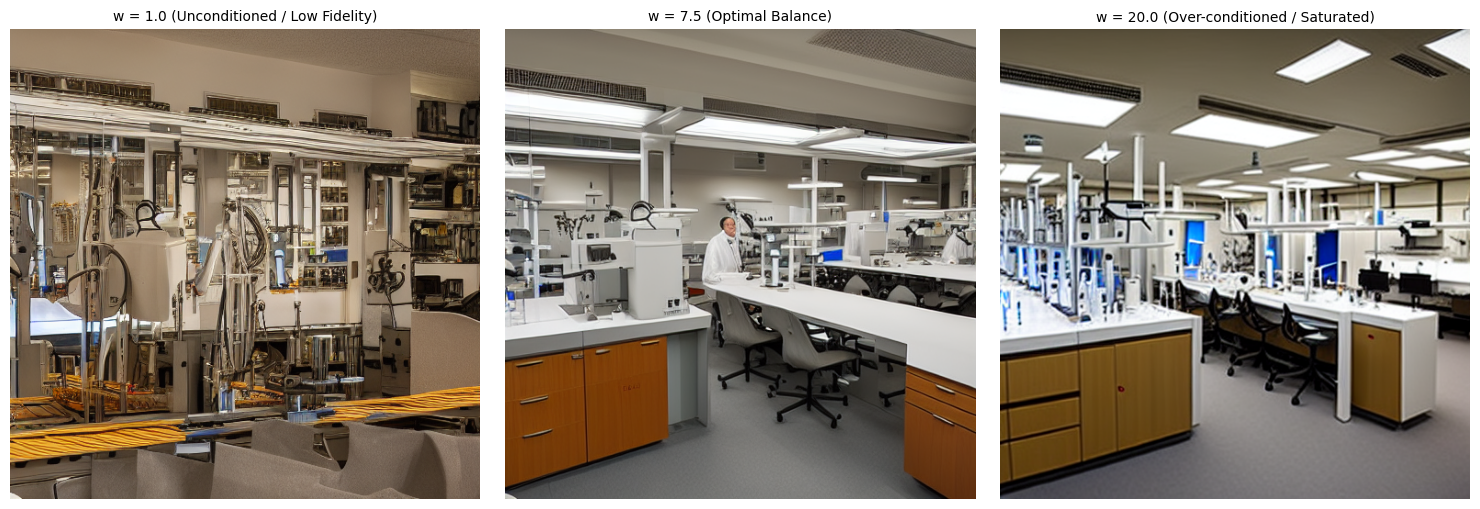

In [ ]:
# Cell 3: CFG Scale Comparison Demonstration
prompt = "A high-tech research laboratory at Stanford University, ultra detailed"

# Test 3 distinct guidance scales (w)
scales = [1.0, 7.5, 20.0]
results = []

print("Running Classifier-Free Guidance (CFG) experiment...")

for w in scales:
    # Set seed for reproducible latent initializations across runs
    generator = torch.Generator(device=device).manual_seed(42)

    img = pipe(
        prompt=prompt,
        num_inference_steps=20,
        guidance_scale=w,
        generator=generator
    ).images[0]
    results.append(img)

# Display outputs side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = [
    "w = 1.0 (Unconditioned / Low Fidelity)",
    "w = 7.5 (Optimal Balance)",
    "w = 20.0 (Over-conditioned / Saturated)"
]

for i, img in enumerate(results):
    axes[i].imshow(img)
    axes[i].set_title(titles[i], fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Cell 4: Explicit CFG Math Loop which in working behind the scenes

- this code shows the UNet noise prediction loop to demonstrate the formula used in continuous latent space:

$$\boldsymbol{\epsilon}_{\text{guided}} = \boldsymbol{\epsilon}_{\text{uncond}} + w \cdot \left(\boldsymbol{\epsilon}_{\text{cond}} - \boldsymbol{\epsilon}_{\text{uncond}}\right)$$

In [ ]:
# Cell 4: Explicit CFG Step Execution (Manual Forward Step)
import torch

@torch.no_grad()
def manual_cfg_step_demo(pipe, prompt, guidance_scale=7.5):
    """
    Demonstrates how the UNet computes 2 forward passes (unconditioned + conditioned)
    and combines them using the CFG vector formula.
    """
    # 1. Encode Positive Prompt (Conditioned Embeddings)
    text_inputs = pipe.tokenizer(
        prompt, padding="max_length", max_length=pipe.tokenizer.model_max_length, return_tensors="pt"
    ).input_ids.to(device)
    text_embeddings = pipe.text_encoder(text_inputs)[0]

    # 2. Encode Empty Prompt (Unconditioned Embeddings)
    uncond_inputs = pipe.tokenizer(
        "", padding="max_length", max_length=pipe.tokenizer.model_max_length, return_tensors="pt"
    ).input_ids.to(device)
    uncond_embeddings = pipe.text_encoder(uncond_inputs)[0]

    # 3. Concatenate into single batch (Batch Size = 2) for parallel GPU execution
    encoder_hidden_states = torch.cat([uncond_embeddings, text_embeddings])

    # 4. Dummy latent sample at time step t
    latents = torch.randn((1, 4, 64, 64), dtype=pipe.unet.dtype, device=device)
    latent_model_input = torch.cat([latents] * 2) # Duplicate latents for batching
    timestep = torch.tensor([500], device=device) # t = 500

    # 5. UNet Forward Pass
    noise_pred = pipe.unet(latent_model_input, timestep, encoder_hidden_states=encoder_hidden_states).sample

    # 6. Separate Unconditional and Conditional noise predictions
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)

    # 7. Apply Classifier-Free Guidance Formula
    noise_pred_guided = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

    print(f"Unconditional Noise Norm : {noise_pred_uncond.norm().item():.4f}")
    print(f"Conditional Noise Norm   : {noise_pred_text.norm().item():.4f}")
    print(f"Guided Noise Norm (w={guidance_scale}): {noise_pred_guided.norm().item():.4f}")

# Execute manual CFG demo
manual_cfg_step_demo(pipe, "A futuristic robot studying computer vision")

Unconditional Noise Norm : 119.9375
Conditional Noise Norm   : 119.4375
Guided Noise Norm (w=7.5): 117.8750


Cell 5: Prompt Engineering Lab (Basic vs. Structured)

- Let us demonstrate how structured prompt engineering improves generation quality by controlling Subject, Environment, Style, Lighting, and Negative Prompts.

Generating images to compare Prompt Engineering strategies...


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

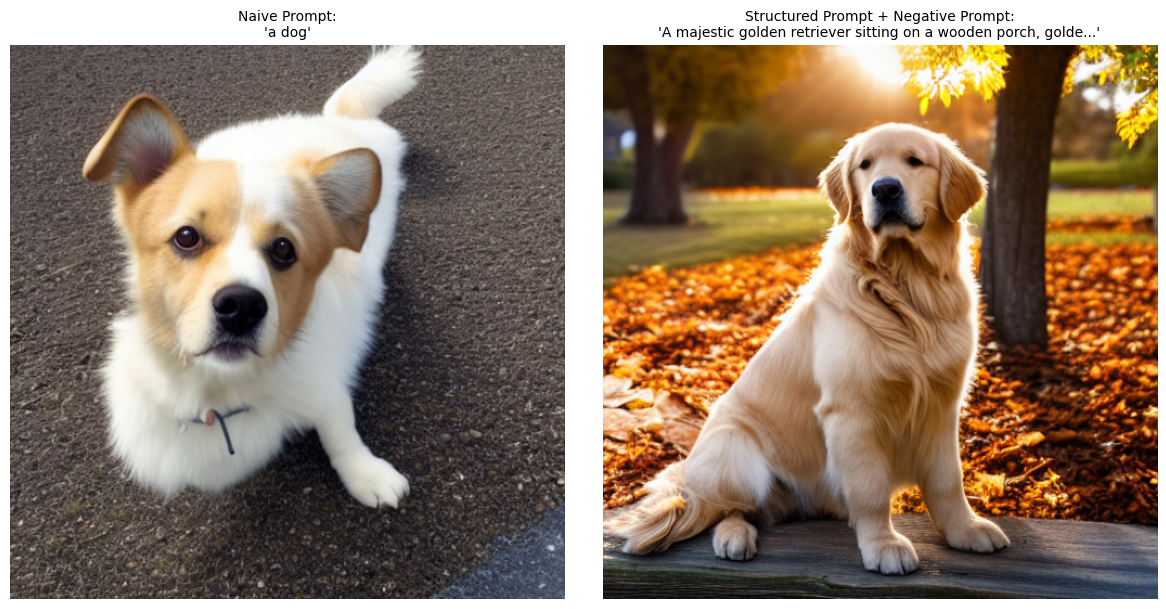

In [ ]:
# Cell 5: Prompt Engineering Comparison Lab
generator = torch.Generator(device=device).manual_seed(101)

# 1. Naive / Naive Prompt
naive_prompt = "a dog"

# 2. Structured Engineered Prompt
engineered_prompt = (
    "A majestic golden retriever sitting on a wooden porch, "  # Subject & Action
    "golden hour warm lighting, autumn leaves in background, "  # Environment & Lighting
    "highly detailed, 8k resolution, cinematic camera shot, 85mm lens" # Style & Render details
)

# 3. Negative Prompt (Explicitly penalizes undesired image attributes during CFG)
negative_prompt = "blurry, low quality, distorted, extra limbs, ugly, oversaturated"

print("Generating images to compare Prompt Engineering strategies...")

# Run Generation 1: Naive Prompt
img_naive = pipe(
    prompt=naive_prompt,
    num_inference_steps=20,
    guidance_scale=7.5,
    generator=generator
).images[0]

# Reset seed for fair comparison
generator = torch.Generator(device=device).manual_seed(101)

# Run Generation 2: Engineered Prompt + Negative Prompt
img_engineered = pipe(
    prompt=engineered_prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=20,
    guidance_scale=7.5,
    generator=generator
).images[0]

# Display comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_naive)
axes[0].set_title(f"Naive Prompt:\n'{naive_prompt}'", fontsize=10)
axes[0].axis("off")

axes[1].imshow(img_engineered)
axes[1].set_title(f"Structured Prompt + Negative Prompt:\n'{engineered_prompt[:60]}...'", fontsize=10)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Benefits of Classifier Free Guidance in Diffusion Models

- Diffusion models trained with CFG learn both conditional score estimates $s_\theta(x_t \vert{} c)$ and unconditional score estimates $s_\theta(x_t \vert{} \emptyset)$ within a single network. At inference time, taking the vector difference pushes the generated sample towards condition $c$ and away from empty space $\emptyset$.

- Computational Cost of CFG: Because CFG requires evaluating both $s_\theta(x_t \vert{} c)$ and $s_\theta(x_t \vert{} \emptyset)$, every single sampling step requires 2 forward passes through the UNet/DiT backbone.

- Role of Negative Prompts: Negative prompts replace the empty token $\emptyset$ with an explicit negative description $c_{\text{neg}}$, steering the ODE/SDE trajectory away from unwanted visual artifacts.